## Loading the results

RESCO writes one JSON file per run, with per-episode metrics keyed by a run hash. 
This section pulls every typed run (Cologne1 and Ingolstadt1, all three algorithms) 
into one combined table so I can compare them directly.

In [5]:
# imports + path to where RESCO saved the results

import os
import json
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "../RESCO/results"

In [6]:
# pulls scenario and algorithm out of a result filename
# e.g. cologne1typed+idqn_libsumo@... -> ("cologne1", "idqn")

def parse_run_name(filename):
    name = filename.replace(".json", "")
    scenario, rest = name.split("typed+")
    algorithm, _ = rest.split("_libsumo")
    return scenario, algorithm

print(parse_run_name('cologne1typed+idqn_libsumo@False_gui@False_f7d3ebe8c2102f8b.json'))

('cologne1', 'idqn')


In [7]:
# reads one run's JSON into a list of per-episode rows

def load_run(filepath):
    scenario, algorithm = parse_run_name(os.path.basename(filepath))
    with open(filepath) as f:
        data = json.load(f)

    run_hash = list(data["rewards"].keys())[0]
    n_episodes = len(data["rewards"][run_hash])

    rows = []
    for ep in range(n_episodes):
        row = {"scenario": scenario, "algorithm": algorithm, "episode": ep + 1}
        for metric in data:
            row[metric] = data[metric][run_hash][ep]
        rows.append(row)
    return rows

rows = load_run(os.path.join(RESULTS_DIR, "cologne1typed+idqn_libsumo@False_gui@False_d54ffcc7f0d0398e.json"))
print('episodes loaded:', len(rows))
print('first row:', rows[0])
print('last row:', rows[-1])

episodes loaded: 99
first row: {'scenario': 'cologne1', 'algorithm': 'idqn', 'episode': 1, 'timeLoss': 327.81024317617863, 'duration': 199.9578163771712, 'waitingTime': 109.84416873449132, 'rewards': -9723.237170596394, 'max_queues': 24.220527045769764, 'queue_lengths': 82.00554785020805, 'vehicles': 2015.0, 'phase_length': 5.743411927877947}
last row: {'scenario': 'cologne1', 'algorithm': 'idqn', 'episode': 99, 'timeLoss': 36.85321091811411, 'duration': 58.687841191067, 'waitingTime': 20.941439205955334, 'rewards': -346.85714285714283, 'max_queues': 5.332871012482663, 'queue_lengths': 13.592233009708737, 'vehicles': 2015.0, 'phase_length': 13.073509015256588}


In [8]:
# load every typed run in the results folder into one table

all_rows = []
for filename in os.listdir(RESULTS_DIR):
    if filename.endswith(".json") and "typed+" in filename:
        all_rows.extend(load_run(os.path.join(RESULTS_DIR, filename)))

results = pd.DataFrame(all_rows)
results.head()

,scenario,algorithm,episode,timeLoss,duration,waitingTime,rewards,max_queues,queue_lengths,vehicles,phase_length
0,cologne1,fixed,1,61.537940,78.774690,39.652109,-1042.191401,10.048544,26.646325,2015.0,15.993065
1,cologne1,fixed,2,58.126060,75.700248,37.679901,-1017.173370,9.345354,24.522885,2015.0,16.034674
2,cologne1,fixed,3,53.318938,71.460050,33.930521,-812.615811,8.764216,22.364771,2015.0,15.993065
3,cologne1,fixed,4,53.819295,72.690323,34.785112,-861.930652,9.123440,23.350902,2015.0,16.034674
4,cologne1,fixed,5,58.585777,76.533002,38.274938,-1008.352288,9.693481,25.647712,2015.0,15.993065


Now I have one DataFrame (`results`) with one row per episode per run — 
99 or 100 rows for each of the six scenario/algorithm combinations. 
Everything from here works off this table.

## Smoothing and plotting learning curves

Raw per-episode reward is noisy, since each episode draws different random traffic 
demand — a single bad episode doesn't mean the policy got worse. I smooth with a 
rolling average (same idea RESCO's own paper uses) to see the actual trend, then 
plot each algorithm's curve per city. If IDQN is actually learning, its curve should 
trend downward and settle below the Fixed-Time and Max-Pressure lines by the end 
of training.

In [9]:
# smooth reward per (scenario, algorithm) so single noisy episodes don't dominate the trend

results = results.sort_values(["scenario", "algorithm", "episode"])
results["reward_smoothed"] = (
    results.groupby(["scenario", "algorithm"])["rewards"]
    .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
)

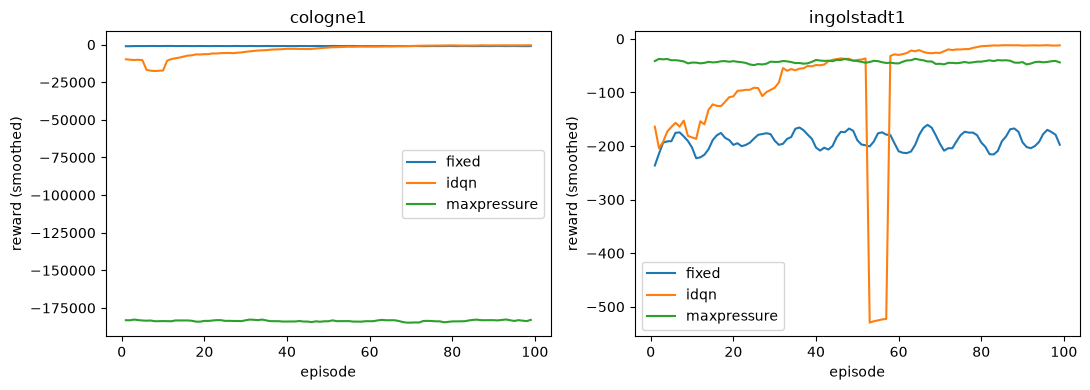

In [10]:
# one subplot per city, one line per algorithm

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, scenario in zip(axes, ["cologne1", "ingolstadt1"]):
    subset = results[results["scenario"] == scenario]
    for algorithm, alg_data in subset.groupby("algorithm"):
        ax.plot(alg_data["episode"], alg_data["reward_smoothed"], label=algorithm)
    ax.set_title(scenario)
    ax.set_xlabel("episode")
    ax.set_ylabel("reward (smoothed)")
    ax.legend()
plt.tight_layout()

IDQN shows real learning on both networks: on Ingolstadt1, it starts worse than 
both baselines, dips sharply around episode 50 before recovering, and converges 
to a clear improvement over Fixed-Time and Max-Pressure by episode 100. On 
Cologne1, IDQN converges to roughly match Fixed-Time's already-strong performance.

Max-Pressure on Cologne1 needs a closer look before it goes in any comparison 
table: its reward sits around -180,000 for the entire run, two orders of 
magnitude worse than Fixed-Time or IDQN on the same network. This lines up with 
Max-Pressure on Cologne1 being the one run that took 41.5 minutes earlier — 
nearly double every other run — which suggests genuine gridlock behavior on 
this specific network rather than a fluke or a plotting artifact.

Next: pull the converged (final-episodes) numbers into an actual results table — 
and check the Max-Pressure/Cologne1 anomaly before trusting it in that table.